# MNIST Handwritten Digit Classification
This project implements a Convolutional Neural Network (CNN) using PyTorch to classify handwritten digits. The architecture features dual convolutional blocks with Batch Normalization and Average Pooling to achieve high accuracy and robust feature extraction.

### 1. Model Training and Evaluation
Defining a CNN with 2 convolution blocks (each containing Conv2d, ReLU, BatchNorm2d, and AvgPool2d), training for 5 epochs, and saving the performance metrics.

✓ Saved best model (Val Acc: 0.9859)
✓ Saved best model (Val Acc: 0.9878)
✓ Saved best model (Val Acc: 0.9894)
✓ Saved best model (Val Acc: 0.9916)

✅ Models saved to 'saved_models/' directory:
   - best_model.pth (checkpoint with best val accuracy)
   - final_model_weights.pth (weights only)
   - full_model.pth (entire model object)
   - mnist_cnn_complete.pth (complete with metadata)


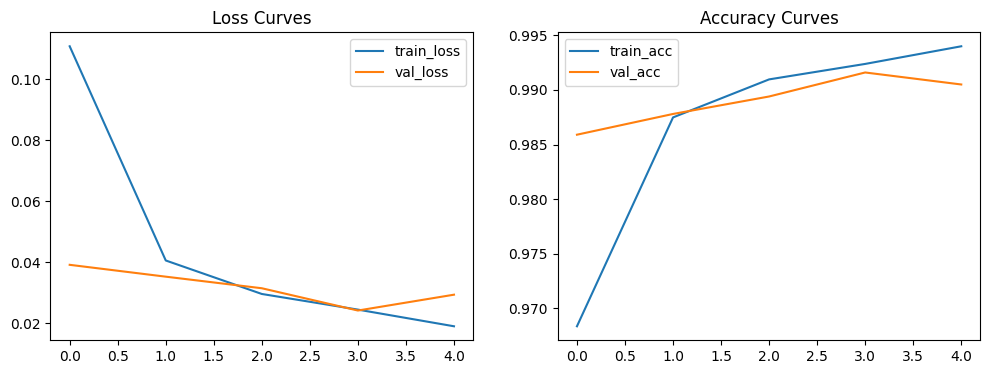

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.98      1.00      0.99      1032
           3       0.98      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.98      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import os

# Create directory for saved models
os.makedirs('saved_models', exist_ok=True)

# Load data
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

# CNN Model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),  # ← ADDED (assignment requirement)
            nn.BatchNorm2d(16),
            nn.AvgPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),  # ← ADDED
            nn.BatchNorm2d(32),
            nn.AvgPool2d(2)
        )

        self.fc = nn.Linear(32*7*7, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_loss, val_loss = [], []
train_acc, val_acc = [], []

best_val_acc = 0  # ← Track best model

# Training loop
for epoch in range(5):
    model.train()
    correct, total, loss_sum = 0, 0, 0

    for x, y in train_loader:
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        _, pred = torch.max(out, 1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_loss.append(loss_sum/len(train_loader))
    train_acc.append(correct/total)

    # Validation
    model.eval()
    correct, total, loss_sum = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in test_loader:
            out = model(x)
            loss = criterion(out, y)
            loss_sum += loss.item()

            _, pred = torch.max(out, 1)
            correct += (pred == y).sum().item()
            total += y.size(0)

            all_preds.extend(pred.numpy())
            all_labels.extend(y.numpy())

    val_loss.append(loss_sum/len(test_loader))
    val_acc.append(correct/total)

    # Save best model based on validation accuracy
    if val_acc[-1] > best_val_acc:
        best_val_acc = val_acc[-1]
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc[-1],
            'train_acc': train_acc[-1],
        }, 'saved_models/best_model.pth')
        print(f"✓ Saved best model (Val Acc: {val_acc[-1]:.4f})")

# Save final model (for assignment)
torch.save(model.state_dict(), 'saved_models/final_model_weights.pth')

# Save entire model (easy loading for Streamlit)
torch.save(model, 'saved_models/full_model.pth')

# Save model architecture separately (good practice)
torch.save({
    'model_class': CNN,
    'state_dict': model.state_dict(),
    'input_shape': (1, 28, 28),
    'num_classes': 10
}, 'saved_models/mnist_cnn_complete.pth')

print("\n✅ Models saved to 'saved_models/' directory:")
print("   - best_model.pth (checkpoint with best val accuracy)")
print("   - final_model_weights.pth (weights only)")
print("   - full_model.pth (entire model object)")
print("   - mnist_cnn_complete.pth (complete with metadata)")

# Plot
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_loss, label='train_loss')
plt.plot(val_loss, label='val_loss')
plt.legend()
plt.title('Loss Curves')
plt.savefig('saved_models/loss_plot.png')  # ← Save plot for assignment

plt.subplot(1,2,2)
plt.plot(train_acc, label='train_acc')
plt.plot(val_acc, label='val_acc')
plt.legend()
plt.title('Accuracy Curves')
plt.savefig('saved_models/accuracy_plot.png')  # ← Save plot for assignment
plt.show()

# Class-wise metrics
report = classification_report(all_labels, all_preds)
print(report)

# Save classification report to file
with open('saved_models/classification_report.txt', 'w') as f:
    f.write(report)

### 2. Visual Verification
Displaying a grid of test images with their predicted labels.

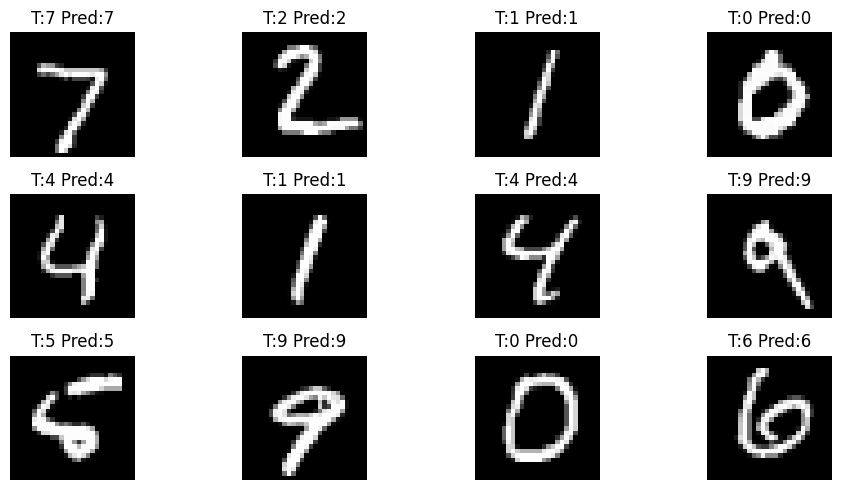

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(12):   # show 12 images
    img, label = test_dataset[i]

    img_tensor = img.unsqueeze(0)

    with torch.no_grad():
        pred = torch.argmax(model(img_tensor), dim=1).item()

    plt.subplot(3,4,i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"T:{label} Pred:{pred}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### 3. Single Image (random image from the test set) Prediction
Loading the saved weights and testing the model on a random image from the test set.

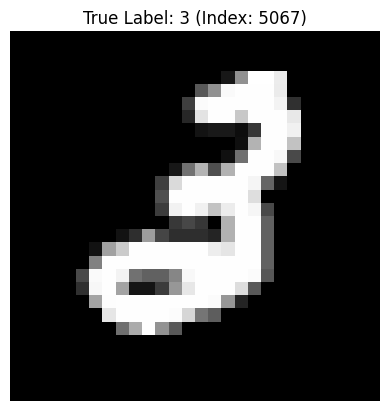

Predicted: 3
Confidence: 99.74%


In [37]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import random

# 🔹 CNN definition (same as before)
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.AvgPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.AvgPool2d(2)
        )

        self.fc = nn.Linear(32*7*7, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# 🔹 Load model
model = CNN()
model.load_state_dict(torch.load("saved_models/final_model_weights.pth", map_location="cpu"))
model.eval()

# 🔹 Load dataset
transform = transforms.ToTensor()
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

# 🔹 Pick RANDOM image
idx = random.randint(0, len(test_dataset)-1)
img, label = test_dataset[idx]

# 🔹 Show image
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"True Label: {label} (Index: {idx})")
plt.axis('off')
plt.show()

# 🔹 Predict
img_tensor = img.unsqueeze(0)

with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)
    pred = torch.argmax(probs, dim=1).item()

# 🔹 Print results
print(f"Predicted: {pred}")
print(f"Confidence: {probs[0][pred]*100:.2f}%")

### 4. Validation and Visualization
Extracting and plotting feature maps and focus heatmaps to understand model internal logic.

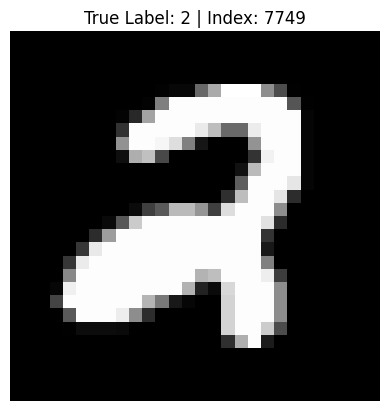

Predicted: 2
Confidence: 100.00%


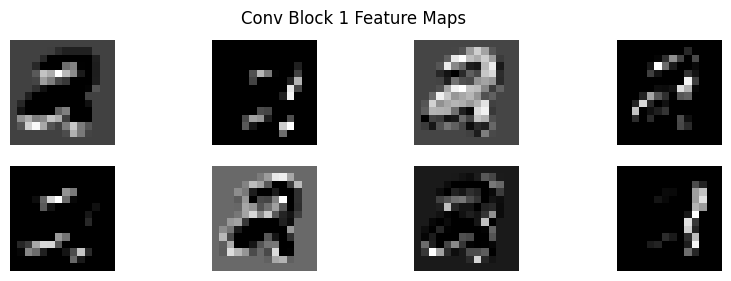

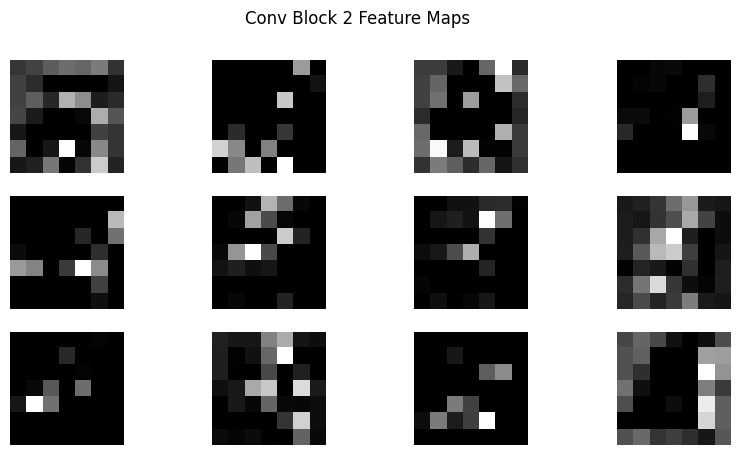

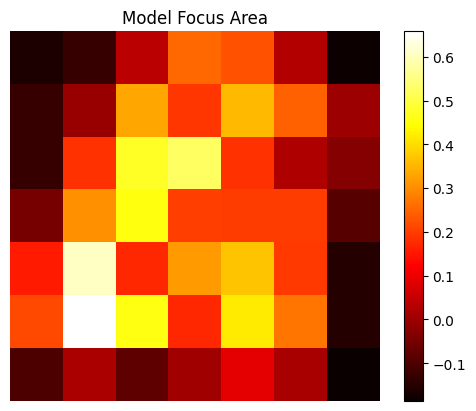

In [27]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import random

# 🔹 CNN (SAME as training)
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.AvgPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.AvgPool2d(2)
        )

        self.fc = nn.Linear(32*7*7, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

# 🔹 Load trained weights
model = CNN()
model.load_state_dict(torch.load("saved_models/final_model_weights.pth", map_location="cpu"))
model.eval()

# 🔹 Load MNIST dataset
transform = transforms.ToTensor()
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)

# 🔹 Pick random image
idx = random.randint(0, len(test_dataset)-1)
img, label = test_dataset[idx]

# 🔹 Show original image
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"True Label: {label} | Index: {idx}")
plt.axis('off')
plt.show()

# 🔹 Prepare input
img_tensor = img.unsqueeze(0)

# 🔹 Forward pass + feature extraction
with torch.no_grad():
    fmap1 = model.block1(img_tensor)   # Conv Block 1
    fmap2 = model.block2(fmap1)        # Conv Block 2

    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)
    pred = torch.argmax(probs, dim=1).item()

# 🔹 Print prediction
print(f"Predicted: {pred}")
print(f"Confidence: {probs[0][pred]*100:.2f}%")

# 🔥 ---- FEATURE MAPS (Block 1) ----
plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(fmap1[0,i].numpy(), cmap='gray')
    plt.axis('off')
plt.suptitle("Conv Block 1 Feature Maps")
plt.show()

# 🔥 ---- FEATURE MAPS (Block 2) ----
plt.figure(figsize=(10,5))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(fmap2[0,i].numpy(), cmap='gray')
    plt.axis('off')
plt.suptitle("Conv Block 2 Feature Maps")
plt.show()

# 🔥 ---- HEATMAP (Focus Area) ----
avg_map = fmap2.mean(dim=1).squeeze()

plt.imshow(avg_map.numpy(), cmap='hot')
plt.colorbar()
plt.title("Model Focus Area")
plt.axis('off')
plt.show()